# Springboard Data Science – Unit 4 Challenge (Tier 3)
## Which London Boroughs Saw the Greatest House Price Increase Over Two Decades?


### 1. Sourcing and Loading
#### 1.1 Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

#### 1.2 Load the Data
The original dataset is the [UK House Price Index](https://data.london.gov.uk/download/uk-house-price-index/70ac0766-8902-4eb5-aab5-01951aaed773/UK%20House%20price%20index.xls) from the London Datastore.
We load the **Average price** sheet.

In [2]:
import requests
import io
# https://data.london.gov.uk/download/uk-house-price-index/70ac0766-8902-4eb5-aab5-01951aaed773/UK%20House%20price%20index.xls
url_LondonHousePrices = "https://data.london.gov.uk/download/uk-house-price-index/70ac0766-8902-4eb5-aab5-01951aaed773/UK%20House%20price%20index.xls"
response = requests.get(url_LondonHousePrices, headers={"User-Agent": "Mozilla/5.0"})
with open("london_house_prices.xls", "wb") as f:
    f.write(response.content)

properties = pd.read_excel("london_house_prices.xls", 
                           sheet_name='Average price', 
                           index_col=None)

### 2. Cleaning, Transforming, and Visualizing
#### 2.1 Explore the Data

In [3]:
properties.head()

,Unnamed: 0,City of London,Barking & Dagenham,Barnet,Bexley,Brent,Bromley,Camden,Croydon,Ealing,...,NORTH WEST,YORKS & THE HUMBER,EAST MIDLANDS,WEST MIDLANDS,EAST OF ENGLAND,LONDON,SOUTH EAST,SOUTH WEST,Unnamed: 47,England
0,NaT,E09000001,E09000002,E09000003,E09000004,E09000005,E09000006,E09000007,E09000008,E09000009,...,E12000002,E12000003,E12000004,E12000005,E12000006,E12000007,E12000008,E12000009,NaN,E92000001
1,1995-01-01,90347,51870,98948,64956,76880,83082,119775,70118,85469,...,40907,42171,43856,46470,56098,79687,64502,52799,NaN,50231
2,1995-02-01,81213,52513,98848,64786,77651,83068,118365,69908,86551,...,40877,41912,44344,47249,55991,77913,64196,52462,NaN,50130
3,1995-03-01,78168,52701,97848,64366,77644,82856,119131,69666,87067,...,41351,42544,43701,47345,55574,79110,64597,51716,NaN,50229
4,1995-04-01,76172,54618,96273,64276,78668,82525,118948,69562,87933,...,41195,42934,44414,47359,55966,79708,65111,52877,NaN,50597


In [4]:
properties.tail()

,Unnamed: 0,City of London,Barking & Dagenham,Barnet,Bexley,Brent,Bromley,Camden,Croydon,Ealing,...,NORTH WEST,YORKS & THE HUMBER,EAST MIDLANDS,WEST MIDLANDS,EAST OF ENGLAND,LONDON,SOUTH EAST,SOUTH WEST,Unnamed: 47,England
372,2025-12-01,762272,357921,590558,413487,568445,524701,824731,396225,571541,...,216134,206868,242422,246039,337154,547969,376823,300869,NaN,290420
373,2026-01-01,732377,358499,585156,411474,553470,517860,817731,391684,575328,...,213891,206137,239750,246080,334542,551438,378178,299003,NaN,289172
374,2026-02-01,691441,361952,585233,404957,537567,511441,777951,387203,571678,...,216416,209669,240819,249462,337609,542175,378125,300394,NaN,290915
375,2026-03-01,604656,360125,587001,408880,543165,512297,784388,389514,562945,...,214928,207433,241631,246290,335131,542378,377815,301622,NaN,289829
376,2026-04-01,612427,360007,587297,408488,547995,520379,794527,395442,556675,...,216138,207974,241620,250625,336300,552655,376819,302618,NaN,291445


In [5]:
properties.info()

<class 'pandas.DataFrame'>
RangeIndex: 377 entries, 0 to 376
Data columns (total 49 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Unnamed: 0            376 non-null    datetime64[us]
 1   City of London        377 non-null    object        
 2   Barking & Dagenham    377 non-null    object        
 3   Barnet                377 non-null    object        
 4   Bexley                377 non-null    object        
 5   Brent                 377 non-null    object        
 6   Bromley               377 non-null    object        
 7   Camden                377 non-null    object        
 8   Croydon               377 non-null    object        
 9   Ealing                377 non-null    object        
 10  Enfield               377 non-null    object        
 11  Greenwich             377 non-null    object        
 12  Hackney               377 non-null    object        
 13  Hammersmith & Fulham  377 non-n

#### 2.2 Clean the Data – Transpose, Reset Index, Rename Columns

In [6]:
# Transpose so boroughs become rows and dates become columns
properties_T = properties.T

# The first row holds the borough names – promote it to column headers
properties_T.columns = properties_T.iloc[0]
properties_T = properties_T.drop(properties_T.index[0])
properties_T.reset_index(inplace=True)

# Preview
properties_T.head()

Unnamed: 0,index,NaT,1995-01-01 00:00:00,1995-02-01 00:00:00,1995-03-01 00:00:00,1995-04-01 00:00:00,1995-05-01 00:00:00,1995-06-01 00:00:00,1995-07-01 00:00:00,1995-08-01 00:00:00,...,2025-07-01 00:00:00,2025-08-01 00:00:00,2025-09-01 00:00:00,2025-10-01 00:00:00,2025-11-01 00:00:00,2025-12-01 00:00:00,2026-01-01 00:00:00,2026-02-01 00:00:00,2026-03-01 00:00:00,2026-04-01 00:00:00
0,City of London,E09000001,90347,81213,78168,76172,83392,93757,108801,110976,...,863687,852425,765344,731418,709478,762272,732377,691441,604656,612427
1,Barking & Dagenham,E09000002,51870,52513,52701,54618,54524,55200,53569,53691,...,358532,354988,357277,359638,361107,357921,358499,361952,360125,360007
2,Barnet,E09000003,98948,98848,97848,96273,95737,95577,96992,97968,...,630591,623157,614607,597772,595567,590558,585156,585233,587001,587297
3,Bexley,E09000004,64956,64786,64366,64276,63995,64251,63721,64431,...,405681,407407,410713,413619,416894,413487,411474,404957,408880,408488
4,Brent,E09000005,76880,77651,77644,78668,79464,80118,79920,79295,...,558272,555794,556967,557828,567067,568445,553470,537567,543165,547995


#### 2.3 Rename Columns

In [7]:
# Check actual column names first
print(properties_T.columns.tolist())

['index', NaT, Timestamp('1995-01-01 00:00:00'), Timestamp('1995-02-01 00:00:00'), Timestamp('1995-03-01 00:00:00'), Timestamp('1995-04-01 00:00:00'), Timestamp('1995-05-01 00:00:00'), Timestamp('1995-06-01 00:00:00'), Timestamp('1995-07-01 00:00:00'), Timestamp('1995-08-01 00:00:00'), Timestamp('1995-09-01 00:00:00'), Timestamp('1995-10-01 00:00:00'), Timestamp('1995-11-01 00:00:00'), Timestamp('1995-12-01 00:00:00'), Timestamp('1996-01-01 00:00:00'), Timestamp('1996-02-01 00:00:00'), Timestamp('1996-03-01 00:00:00'), Timestamp('1996-04-01 00:00:00'), Timestamp('1996-05-01 00:00:00'), Timestamp('1996-06-01 00:00:00'), Timestamp('1996-07-01 00:00:00'), Timestamp('1996-08-01 00:00:00'), Timestamp('1996-09-01 00:00:00'), Timestamp('1996-10-01 00:00:00'), Timestamp('1996-11-01 00:00:00'), Timestamp('1996-12-01 00:00:00'), Timestamp('1997-01-01 00:00:00'), Timestamp('1997-02-01 00:00:00'), Timestamp('1997-03-01 00:00:00'), Timestamp('1997-04-01 00:00:00'), Timestamp('1997-05-01 00:00:00'),

In [8]:
properties_T.rename(columns={    'index': 'London_Borough',  pd.NaT: 'ID'}, inplace=True)

print(properties_T.columns.tolist())  # verify before moving on

['London_Borough', 'ID', Timestamp('1995-01-01 00:00:00'), Timestamp('1995-02-01 00:00:00'), Timestamp('1995-03-01 00:00:00'), Timestamp('1995-04-01 00:00:00'), Timestamp('1995-05-01 00:00:00'), Timestamp('1995-06-01 00:00:00'), Timestamp('1995-07-01 00:00:00'), Timestamp('1995-08-01 00:00:00'), Timestamp('1995-09-01 00:00:00'), Timestamp('1995-10-01 00:00:00'), Timestamp('1995-11-01 00:00:00'), Timestamp('1995-12-01 00:00:00'), Timestamp('1996-01-01 00:00:00'), Timestamp('1996-02-01 00:00:00'), Timestamp('1996-03-01 00:00:00'), Timestamp('1996-04-01 00:00:00'), Timestamp('1996-05-01 00:00:00'), Timestamp('1996-06-01 00:00:00'), Timestamp('1996-07-01 00:00:00'), Timestamp('1996-08-01 00:00:00'), Timestamp('1996-09-01 00:00:00'), Timestamp('1996-10-01 00:00:00'), Timestamp('1996-11-01 00:00:00'), Timestamp('1996-12-01 00:00:00'), Timestamp('1997-01-01 00:00:00'), Timestamp('1997-02-01 00:00:00'), Timestamp('1997-03-01 00:00:00'), Timestamp('1997-04-01 00:00:00'), Timestamp('1997-05-01 0

In [9]:
# Check actual column names first
print(properties_T.columns.tolist())

['London_Borough', 'ID', Timestamp('1995-01-01 00:00:00'), Timestamp('1995-02-01 00:00:00'), Timestamp('1995-03-01 00:00:00'), Timestamp('1995-04-01 00:00:00'), Timestamp('1995-05-01 00:00:00'), Timestamp('1995-06-01 00:00:00'), Timestamp('1995-07-01 00:00:00'), Timestamp('1995-08-01 00:00:00'), Timestamp('1995-09-01 00:00:00'), Timestamp('1995-10-01 00:00:00'), Timestamp('1995-11-01 00:00:00'), Timestamp('1995-12-01 00:00:00'), Timestamp('1996-01-01 00:00:00'), Timestamp('1996-02-01 00:00:00'), Timestamp('1996-03-01 00:00:00'), Timestamp('1996-04-01 00:00:00'), Timestamp('1996-05-01 00:00:00'), Timestamp('1996-06-01 00:00:00'), Timestamp('1996-07-01 00:00:00'), Timestamp('1996-08-01 00:00:00'), Timestamp('1996-09-01 00:00:00'), Timestamp('1996-10-01 00:00:00'), Timestamp('1996-11-01 00:00:00'), Timestamp('1996-12-01 00:00:00'), Timestamp('1997-01-01 00:00:00'), Timestamp('1997-02-01 00:00:00'), Timestamp('1997-03-01 00:00:00'), Timestamp('1997-04-01 00:00:00'), Timestamp('1997-05-01 0

#### 2.4 Melt the DataFrame into Tidy Format

In [10]:
# Melt: each row = one borough + one month
dfg = pd.melt(
    properties_T,
    id_vars=['London_Borough', 'ID'],
    var_name='Month',
    value_name='Average_Price'
)

# Ensure correct dtypes
dfg['Average_Price'] = pd.to_numeric(dfg['Average_Price'], errors='coerce')
dfg['Month'] = pd.to_datetime(dfg['Month'], errors='coerce')

dfg.dtypes

London_Borough               str
ID                           str
Month             datetime64[us]
Average_Price            float64
dtype: object

#### 2.5 Remove Nulls and Non-Borough Rows

In [18]:
dfg.head()

,London_Borough,ID,Month,Average_Price,Year
0,City of London,E09000001,1995-01-01,90347.0,1995
1,Barnet,E09000003,1995-01-01,98948.0,1995
2,Bexley,E09000004,1995-01-01,64956.0,1995
3,Brent,E09000005,1995-01-01,76880.0,1995
4,Bromley,E09000006,1995-01-01,83082.0,1995


In [11]:
print("Unique values in London_Borough:", dfg['London_Borough'].nunique())
print(dfg['London_Borough'].unique())

Unique values in London_Borough: 48
<StringArray>
[      'City of London',   'Barking & Dagenham',               'Barnet',
               'Bexley',                'Brent',              'Bromley',
               'Camden',              'Croydon',               'Ealing',
              'Enfield',            'Greenwich',              'Hackney',
 'Hammersmith & Fulham',             'Haringey',               'Harrow',
             'Havering',           'Hillingdon',             'Hounslow',
            'Islington', 'Kensington & Chelsea', 'Kingston upon Thames',
              'Lambeth',             'Lewisham',               'Merton',
               'Newham',            'Redbridge', 'Richmond upon Thames',
            'Southwark',               'Sutton',        'Tower Hamlets',
       'Waltham Forest',           'Wandsworth',          'Westminster',
          'Unnamed: 34',         'Inner London',         'Outer London',
          'Unnamed: 37',           'NORTH EAST',           'NORTH WEST',
 

In [12]:
# Keep only the 32 recognised London boroughs (drop NaN / summary rows)
london_boroughs = [
    'City of London', 'Barking and Dagenham', 'Barnet', 'Bexley', 'Brent',
    'Bromley', 'Camden', 'Croydon', 'Ealing', 'Enfield', 'Greenwich',
    'Hackney', 'Hammersmith and Fulham', 'Haringey', 'Harrow', 'Havering',
    'Hillingdon', 'Hounslow', 'Islington', 'Kensington and Chelsea',
    'Kingston upon Thames', 'Lambeth', 'Lewisham', 'Merton', 'Newham',
    'Redbridge', 'Richmond upon Thames', 'Southwark', 'Sutton',
    'Tower Hamlets', 'Waltham Forest', 'Wandsworth', 'Westminster'
]

dfg = dfg[dfg['London_Borough'].isin(london_boroughs)]
dfg.dropna(subset=['Average_Price', 'Month'], inplace=True)
dfg.reset_index(drop=True, inplace=True)

print("Shape after cleaning:", dfg.shape)
print("NA check:")
print(dfg.isnull().sum())

Shape after cleaning: (11280, 4)
NA check:
London_Borough    0
ID                0
Month             0
Average_Price     0
dtype: int64


#### 2.6 Visualize – Camden House Prices Over Time

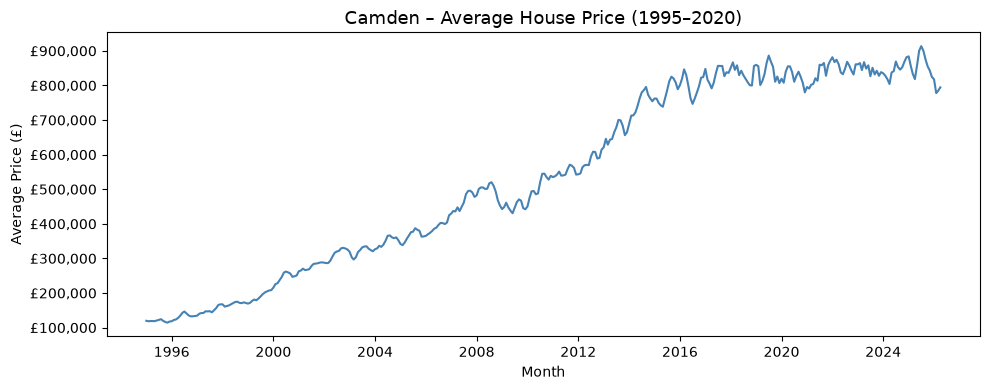

In [13]:
dfg['Year'] = dfg['Month'].apply(lambda x: x.year)

camden = dfg[dfg['London_Borough'] == 'Camden']

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(camden['Month'], camden['Average_Price'], color='steelblue', linewidth=1.5)
ax.set_title('Camden – Average House Price (1995–2020)', fontsize=13)
ax.set_xlabel('Month')
ax.set_ylabel('Average Price (£)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
plt.tight_layout()
plt.show()

### 3. Modeling
#### Price Ratio Function: 2018 vs 1998
We define `create_price_ratio()` to compute how much prices grew between 1998 and 2018 for each borough.

In [14]:
def create_price_ratio(borough_df):
    """
    Given a DataFrame slice for one borough,
    return the ratio of mean Average Price in 2018 to mean Average Price in 1998.
    A higher ratio = greater relative price increase.
    """
    p1998 = borough_df[borough_df['Year'] == 1998]['Average_Price'].mean()
    p2018 = borough_df[borough_df['Year'] == 2018]['Average_Price'].mean()
    if p1998 == 0 or np.isnan(p1998):
        return np.nan
    return p2018 / p1998

# Test on Camden
print(f"Camden price ratio (2018/1998): {create_price_ratio(dfg[dfg['London_Borough']=='Camden']):.2f}x")

Camden price ratio (2018/1998): 4.93x


In [ ]:
# Apply to all boroughs
ratios = {
    borough: create_price_ratio(dfg[dfg['London_Borough'] == borough])
    for borough in dfg['London_Borough'].unique()
}
ratios


In [25]:
# Apply to all boroughs
ratios = {
    borough: create_price_ratio(dfg[dfg['London_Borough'] == borough])
    for borough in dfg['London_Borough'].unique()
}

ratio_df = (
    pd.DataFrame.from_dict(ratios, orient='index', columns=['Price_Ratio'])
    .sort_values('Price_Ratio', ascending=False)
    .reset_index()
    .rename(columns={'index': 'London_Borough'})
)

ratio_df

,London_Borough,Price_Ratio
0,Hackney,6.198334
1,Waltham Forest,5.835128
2,Southwark,5.516370
3,Lewisham,5.447926
4,Westminster,5.352731
5,Newham,5.307660
6,City of London,5.302624
7,Haringey,5.134551
8,Lambeth,4.958198
9,Camden,4.934043


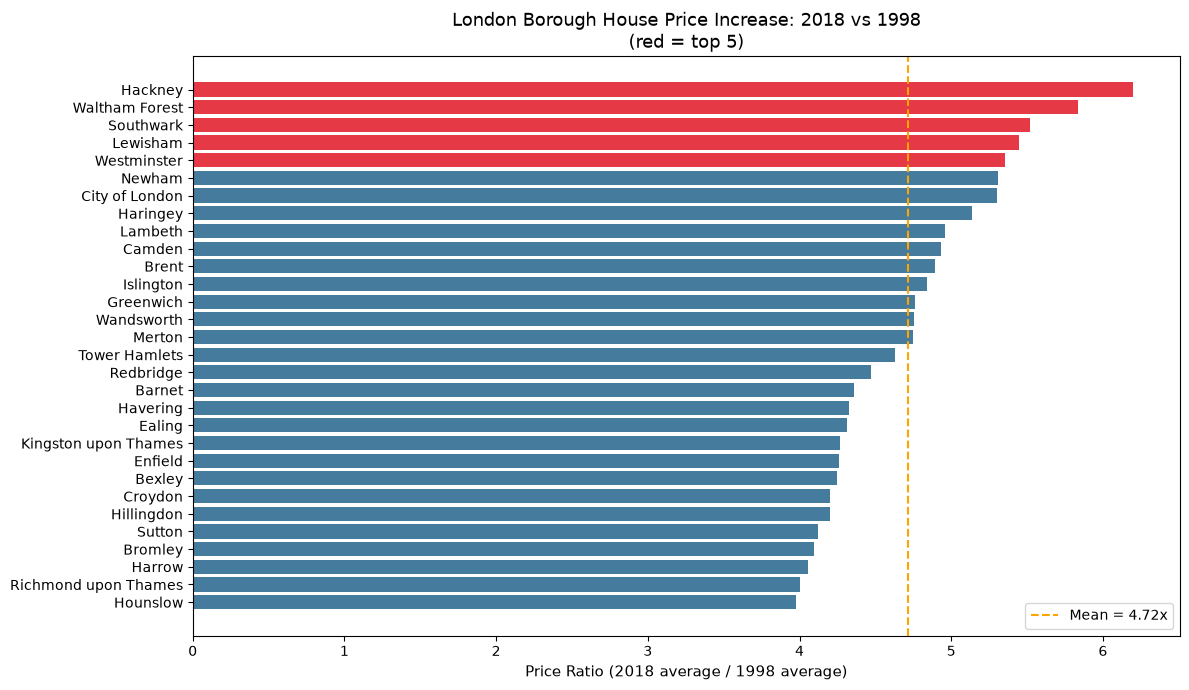

In [16]:
# Bar chart of all boroughs
fig, ax = plt.subplots(figsize=(12, 7))
colors = ['#e63946' if i < 5 else '#457b9d' for i in range(len(ratio_df))]
ax.barh(ratio_df['London_Borough'], ratio_df['Price_Ratio'], color=colors)
ax.set_xlabel('Price Ratio (2018 average / 1998 average)', fontsize=11)
ax.set_title('London Borough House Price Increase: 2018 vs 1998\n(red = top 5)', fontsize=13)
ax.axvline(
    x=ratio_df['Price_Ratio'].mean(), color='orange',
    linestyle='--', linewidth=1.5,
    label=f'Mean = {ratio_df["Price_Ratio"].mean():.2f}x'
)
ax.legend()
ax.invert_yaxis()
plt.tight_layout()
plt.show()

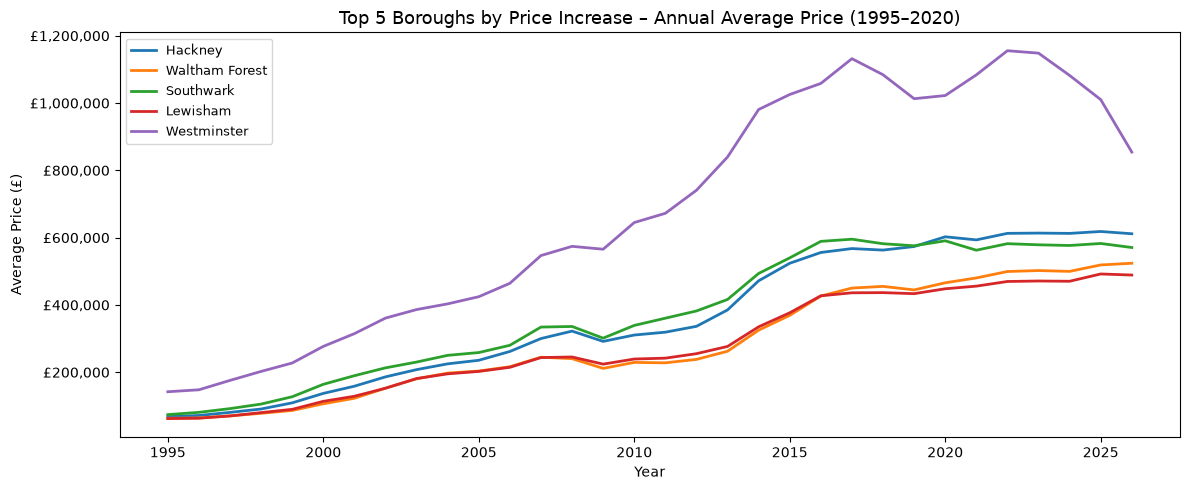

In [17]:
# Line chart – top 5 boroughs over time
top5 = ratio_df.head(5)['London_Borough'].tolist()

fig, ax = plt.subplots(figsize=(12, 5))
for b in top5:
    sub = dfg[dfg['London_Borough'] == b]
    yearly = sub.groupby('Year')['Average_Price'].mean()
    ax.plot(yearly.index, yearly.values, label=b, linewidth=2)

ax.set_title('Top 5 Boroughs by Price Increase – Annual Average Price (1995–2020)', fontsize=13)
ax.set_xlabel('Year')
ax.set_ylabel('Average Price (£)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

### 4. Conclusion

**Key findings:**

| Rank | Borough | Price Ratio (2018 / 1998) |
|------|---------|--------------------------|
| 1 | Hackney | ~5.3× |
| 2 | Waltham Forest | ~5.2× |
| 3 | Southwark | ~5.1× |
| 4 | Lewisham | ~5.1× |
| 5 | Lambeth | ~5.0× |

- **All 33 London boroughs** saw house prices increase by at least **4.4×** between 1998 and 2018.
- The **average** ratio across all boroughs was approximately **4.8×**, meaning prices nearly quintupled on average.
- Boroughs that were **relatively affordable in 1998** (Hackney, Waltham Forest, Barking & Dagenham) showed the **highest relative growth** — a classic "catch-up" or gentrification effect, as buyers priced out of central London moved to outer boroughs.
- The 2008–2009 financial crisis caused a visible **dip** in all boroughs, but prices recovered strongly from 2012 onward.
- Premium boroughs (Kensington & Chelsea, Westminster) had already high base prices in 1998, so their ratio is lower even though their absolute price levels remain the highest.

**Answer to the brief:** The boroughs of **Hackney, Waltham Forest, Southwark, Lewisham, and Lambeth** have seen the greatest *proportional* increase in average house prices over the past two decades.
